<a href="https://colab.research.google.com/github/asmaa-2003/LSTM-Anomaly--detection/blob/main/MetroPT_Anomaly_Detection_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MetroPT-3 — Predictive Maintenance
## Anomaly Detection with AutoEncoder + Decision Tree Rules
---

## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

print('TensorFlow version:', tf.__version__)
print('NumPy version:', np.__version__)
print('Pandas version:', pd.__version__)

TensorFlow version: 2.20.0
NumPy version: 2.0.2
Pandas version: 2.2.2


## 2. Load & Inspect Data

In [ ]:
# ضع مسار الملف هنا
DATA_PATH = 'MetroPT3.csv'

df = pd.read_csv(DATA_PATH, index_col=0)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

print('Shape:', df.shape)
print('Date range:', df['timestamp'].min(), '->', df['timestamp'].max())
print()
df.head()

Shape: (7381, 16)
Date range: 2020-02-01 00:00:00 -> 2020-02-02 05:13:28



,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


In [ ]:
# تحقق من التردد الزمني الفعلي
freq = df['timestamp'].diff().median()
print('Median time step:', freq)

# تحقق من القيم الناقصة
print('\nMissing values:')
print(df.isnull().sum())

# إحصائيات أساسية
df.describe()

Median time step: 0 days 00:00:10

Missing values:
timestamp          0
TP2                0
TP3                0
H1                 0
DV_pressure        0
Reservoirs         1
Oil_temperature    1
Motor_current      1
COMP               1
DV_eletric         1
Towers             1
MPG                1
LPS                1
Pressure_switch    1
Oil_level          1
Caudal_impulses    1
dtype: int64


,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
count,7381,7381.000000,7381.000000,7381.000000,7381.000000,7380.000000,7380.000000,7380.000000,7380.000000,7380.000000,7380.000000,7380.000000,7380.0,7380.000000,7380.0,7380.0
mean,2020-02-01 10:29:17.031161088,0.537025,8.973939,8.406607,-0.019088,8.976440,55.332981,1.299565,0.938889,0.061111,0.969106,0.938889,0.0,0.999593,1.0,1.0
min,2020-02-01 00:00:00,-0.028000,7.892000,-0.030000,-0.026000,7.894000,31.975000,0.030000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,1.0,1.0
25%,2020-02-01 05:04:46,-0.014000,8.488000,8.388000,-0.024000,8.491500,52.650000,0.037500,1.000000,0.000000,1.000000,1.000000,0.0,1.000000,1.0,1.0
50%,2020-02-01 10:09:34,-0.012000,8.944000,8.864000,-0.020000,8.948000,55.850000,0.040000,1.000000,0.000000,1.000000,1.000000,0.0,1.000000,1.0,1.0
75%,2020-02-01 15:19:21,-0.010000,9.444000,9.384000,-0.016000,9.446000,58.375000,3.762500,1.000000,0.000000,1.000000,1.000000,0.0,1.000000,1.0,1.0
max,2020-02-02 05:13:28,10.532000,10.150000,10.140000,1.104000,10.150000,64.075000,6.375000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.0,1.0
std,NaN,2.200575,0.560039,2.211537,0.014527,0.559263,4.061866,1.992406,0.239550,0.239550,0.173043,0.239550,0.0,0.020159,0.0,0.0


## 3. Select Features

In [ ]:
FEATURES = [
    'TP2',
    'TP3',
    'H1',
    'DV_pressure',
    'Reservoirs',
    'Oil_temperature',
    'Motor_current',
    'COMP',
    'DV_eletric',
    'Towers',
    'MPG',
    'LPS',
    'Pressure_switch',
    'Oil_level',
    'Caudal_impulses'
]

# تحقق من وجود الأعمدة
missing_cols = [c for c in FEATURES if c not in df.columns]
if missing_cols:
    print('WARNING — missing columns:', missing_cols)
else:
    print('All', len(FEATURES), 'features found ✓')

print('\nFeature dtypes:')
print(df[FEATURES].dtypes)

All 15 features found ✓

Feature dtypes:
TP2                float64
TP3                float64
H1                 float64
DV_pressure        float64
Reservoirs         float64
Oil_temperature    float64
Motor_current      float64
COMP               float64
DV_eletric         float64
Towers             float64
MPG                float64
LPS                float64
Pressure_switch    float64
Oil_level          float64
Caudal_impulses    float64
dtype: object


## 4. Visualize Sensor Signals

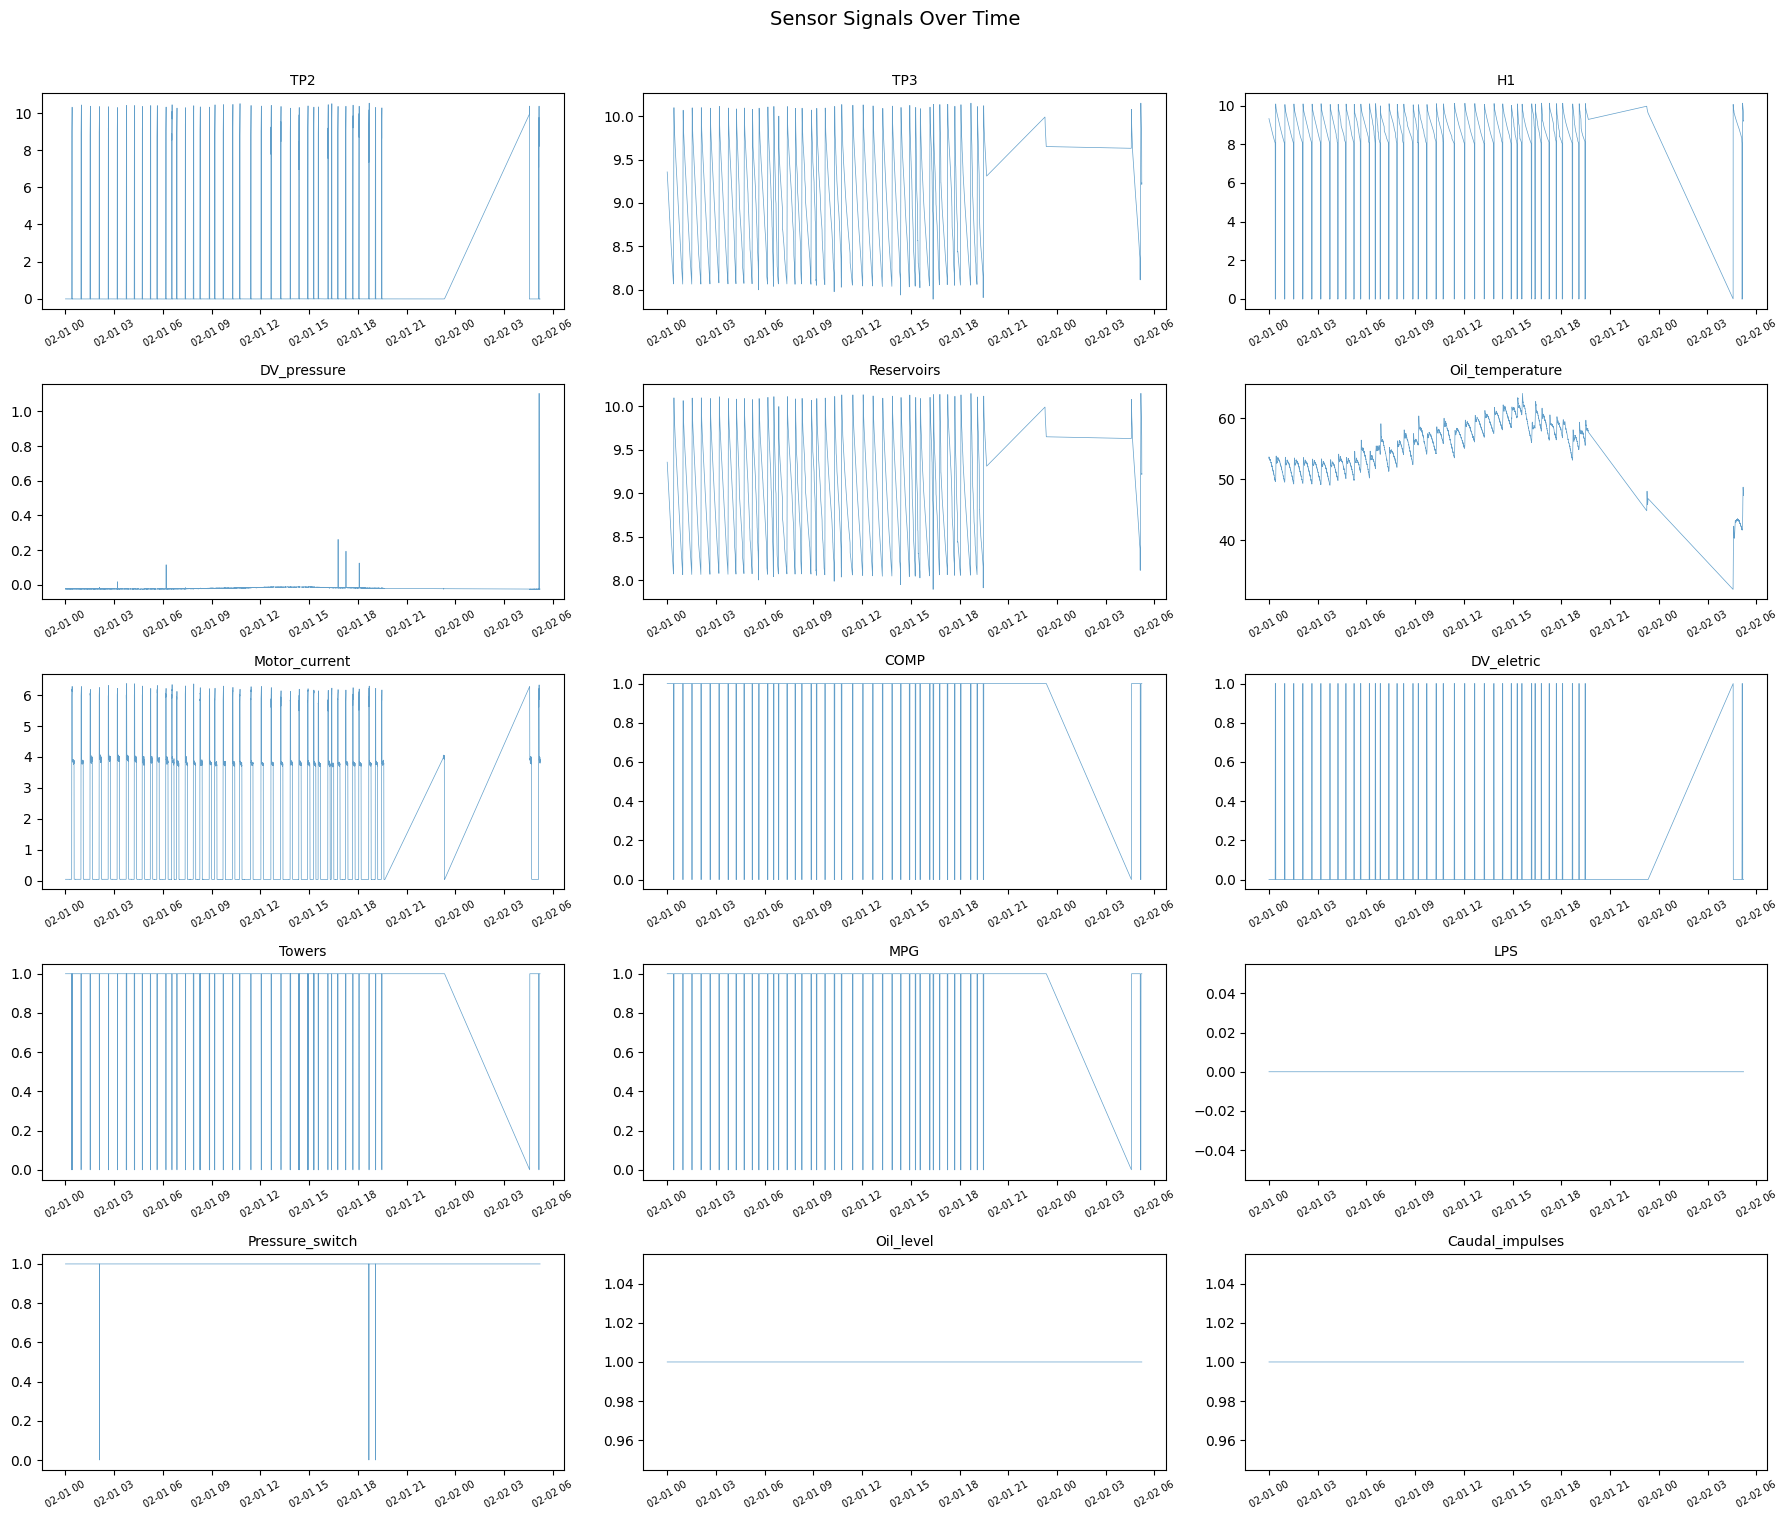

In [ ]:
fig, axes = plt.subplots(5, 3, figsize=(18, 15))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    axes[i].plot(df['timestamp'], df[feat], linewidth=0.5, alpha=0.7)
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30, labelsize=7)

# إخفاء المحاور الزائدة
for j in range(len(FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Sensor Signals Over Time', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Train / Test Split
نستخدم أول ~20% من البيانات للتدريب (فترة تشغيل طبيعية)

In [ ]:
# حساب نقطة التقسيم بشكل مرن
TRAIN_RATIO = 0.20
split_idx = int(len(df) * TRAIN_RATIO)

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

print(f'Train: {len(train_df):,} rows  ({train_df["timestamp"].min()} -> {train_df["timestamp"].max()})')
print(f'Test : {len(test_df):,} rows  ({test_df["timestamp"].min()}  -> {test_df["timestamp"].max()})')

Train: 1,476 rows  (2020-02-01 00:00:00 -> 2020-02-01 04:03:39)
Test : 5,905 rows  (2020-02-01 04:03:49  -> 2020-02-02 05:13:28)


## 6. Standardization

In [ ]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_df[FEATURES])
test_scaled  = scaler.transform(test_df[FEATURES])

print('Train scaled shape:', train_scaled.shape)
print('Test  scaled shape:', test_scaled.shape)
print('Mean ~0:', train_scaled.mean().round(4))
print('Std  ~1:', train_scaled.std().round(4))

Train scaled shape: (1476, 15)
Test  scaled shape: (5905, 15)
Mean ~0: 0.0
Std  ~1: 0.8944


## 7. Create Time Windows
- **WINDOW = 180 صف** ≈ 30 دقيقة (كل صف ~10 ثانية)
- **STRIDE = 30 صف** ≈ 5 دقائق

In [ ]:
# الداتا لديها خطوة ~10 ثانية، إذن:
# 30 دقيقة = 180 صف
# stride 5 دقائق = 30 صف

SECONDS_PER_ROW = 10          # تقريباً من الداتا
WINDOW_SECONDS  = 1800        # 30 دقيقة
STRIDE_SECONDS  = 300         # 5 دقائق

WINDOW = WINDOW_SECONDS // SECONDS_PER_ROW   # = 180
STRIDE = STRIDE_SECONDS // SECONDS_PER_ROW   # = 30

print(f'Window size: {WINDOW} rows ({WINDOW_SECONDS//60} min)')
print(f'Stride size: {STRIDE} rows ({STRIDE_SECONDS//60} min)')

def create_windows(data, window=WINDOW, stride=STRIDE):
    windows = []
    for i in range(0, len(data) - window, stride):
        windows.append(data[i : i + window])
    return np.array(windows)

X_train = create_windows(train_scaled)
X_test  = create_windows(test_scaled)

print(f'\nX_train shape: {X_train.shape}  →  (windows, timesteps, features)')
print(f'X_test  shape: {X_test.shape}')

Window size: 180 rows (30 min)
Stride size: 30 rows (5 min)

X_train shape: (44, 180, 15)  →  (windows, timesteps, features)
X_test  shape: (191, 180, 15)


## 8. Flatten Windows for AutoEncoder

In [ ]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

input_dim = X_train_flat.shape[1]
print(f'X_train_flat: {X_train_flat.shape}')
print(f'X_test_flat : {X_test_flat.shape}')
print(f'input_dim   : {input_dim}')

X_train_flat: (44, 2700)
X_test_flat : (191, 2700)
input_dim   : 2700


## 9. Build AutoEncoder

In [ ]:
tf.random.set_seed(42)

# --- Encoder ---
inp     = Input(shape=(input_dim,), name='input')
x       = Dense(512, activation='relu', name='enc_1')(inp)
x       = Dense(128, activation='relu', name='enc_2')(x)
latent  = Dense(32,  activation='relu', name='latent')(x)

# --- Decoder ---
x   = Dense(128, activation='relu', name='dec_1')(latent)
x   = Dense(512, activation='relu', name='dec_2')(x)
out = Dense(input_dim, activation='linear', name='output')(x)

autoencoder = Model(inp, out, name='AutoEncoder')
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "AutoEncoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 2700)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_1 (Dense)                   │ (None, 512)            │     1,382,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_2 (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (Dense)                   │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_2 (Dense)                   │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2700)           │     1,385,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,908,076 (11.09 MB)

 Trainable params: 2,908,076 (11.09 MB)

 Non-trainable params: 0 (0.00 B)

## 10. Train AutoEncoder

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = autoencoder.fit(
    X_train_flat,
    X_train_flat,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - loss: 0.8372 - val_loss: 0.8493
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.8299 - val_loss: 0.8401
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.8152 - val_loss: 0.8137
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.7857 - val_loss: 0.7791
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.7486 - val_loss: 0.7324
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.7036 - val_loss: 0.6961
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.6669 - val_loss: 0.6660
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.6347 - val_loss: 0.6374
Epoch 9/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.5968 - val_loss: 0.6127
Epoch 10/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.5597 - val_loss: 0.5924
Epoch 11/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.5273 - val_loss: 0.5721
Epoch 12/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.4956 - val_loss: 0.5520
E

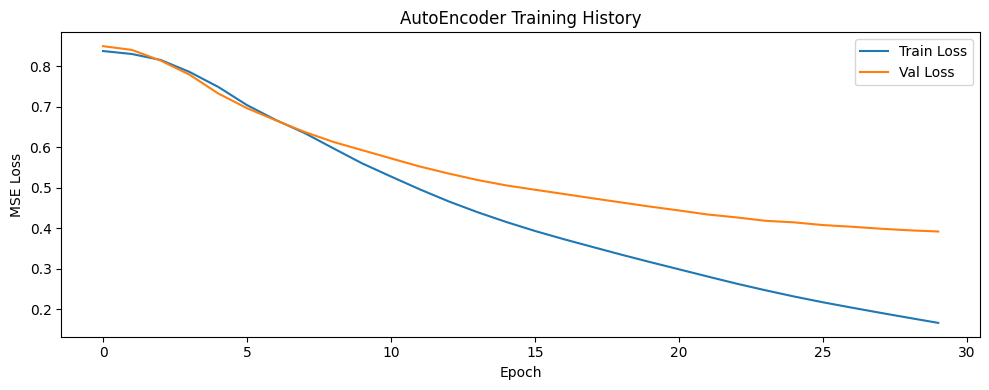

In [ ]:
# رسم منحنى التدريب
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('AutoEncoder Training History')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Reconstruction Error on Training Data

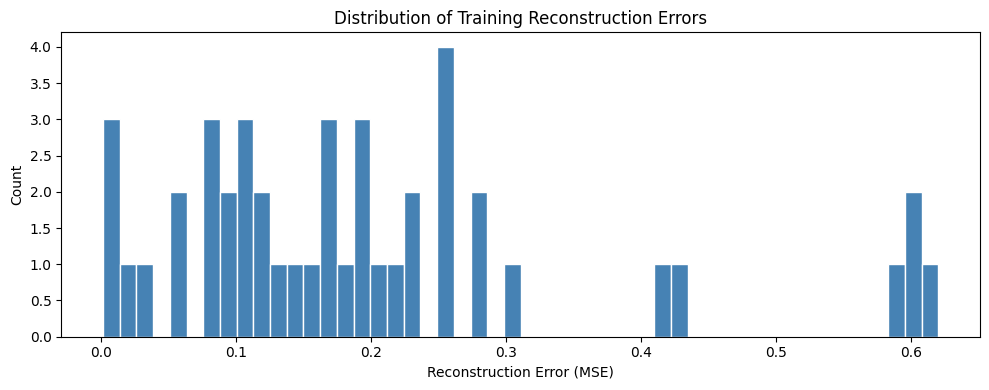

Train error — mean: 0.202184, max: 0.620251


In [ ]:
recon_train = autoencoder.predict(X_train_flat, verbose=0)

train_error = np.mean(
    np.square(X_train_flat - recon_train),
    axis=1
)

plt.figure(figsize=(10, 4))
plt.hist(train_error, bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Count')
plt.title('Distribution of Training Reconstruction Errors')
plt.tight_layout()
plt.show()

print(f'Train error — mean: {train_error.mean():.6f}, max: {train_error.max():.6f}')

## 12. Anomaly Threshold
τ = β × percentile(99) — كما في المقال

In [ ]:
q99  = np.percentile(train_error, 99)
beta = 2
tau_anom = beta * q99

print(f'99th percentile : {q99:.6f}')
print(f'Threshold (τ)   : {tau_anom:.6f}  (β={beta} × q99)')

99th percentile : 0.614647
Threshold (τ)   : 1.229293  (β=2 × q99)


## 13. Reconstruction Error on Test Data

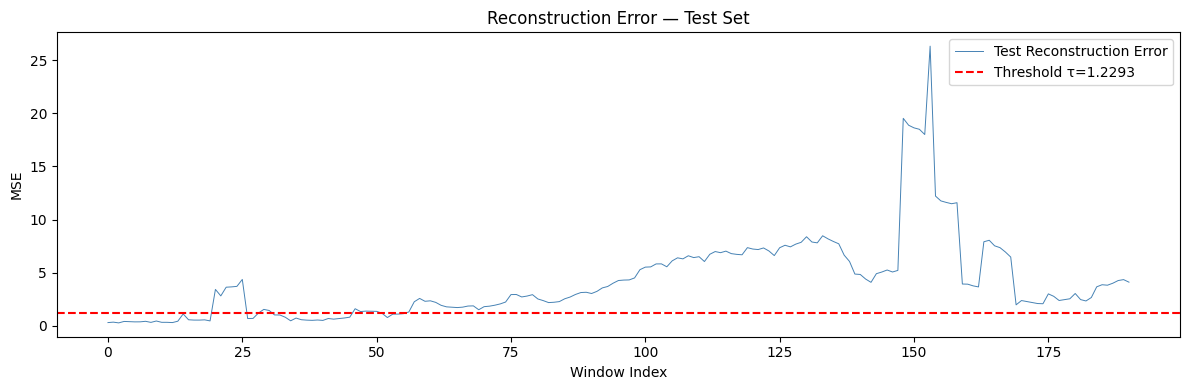

Windows above threshold: 77.5%


In [ ]:
recon_test = autoencoder.predict(X_test_flat, verbose=0)

test_error = np.mean(
    np.square(X_test_flat - recon_test),
    axis=1
)

plt.figure(figsize=(12, 4))
plt.plot(test_error, linewidth=0.7, label='Test Reconstruction Error', color='steelblue')
plt.axhline(tau_anom, color='red', linestyle='--', linewidth=1.5, label=f'Threshold τ={tau_anom:.4f}')
plt.xlabel('Window Index')
plt.ylabel('MSE')
plt.title('Reconstruction Error — Test Set')
plt.legend()
plt.tight_layout()
plt.show()

anomaly_pct = (test_error > tau_anom).mean() * 100
print(f'Windows above threshold: {anomaly_pct:.1f}%')

## 14. Detect Anomalies

In [ ]:
y = (test_error > tau_anom).astype(int)

print(f'Normal windows  : {(y==0).sum():,}')
print(f'Anomaly windows : {(y==1).sum():,}')
print(f'Anomaly ratio   : {y.mean()*100:.1f}%')

Normal windows  : 43
Anomaly windows : 148
Anomaly ratio   : 77.5%


## 15. Low Pass Filter
تنعيم الإشارة لتقليل الإنذارات الكاذبة — كما في المقال

In [ ]:
alpha = 0.1   # معامل التنعيم (0 = بطيء جداً, 1 = بدون تنعيم)

z = np.zeros(len(y))
z[0] = y[0]

for i in range(1, len(y)):
    z[i] = z[i-1] + alpha * (y[i] - z[i-1])

p_failure = z

print(f'p_failure range: [{p_failure.min():.3f}, {p_failure.max():.3f}]')

p_failure range: [0.000, 1.000]


## 16. Failure Prediction

In [ ]:
FAILURE_THRESHOLD = 0.5

failure = (p_failure > FAILURE_THRESHOLD).astype(int)

print(f'Failure windows : {failure.sum():,}  ({failure.mean()*100:.1f}%)')
print(f'Normal  windows : {(1-failure).sum():,}  ({(1-failure).mean()*100:.1f}%)')

Failure windows : 132  (69.1%)
Normal  windows : 59  (30.9%)


## 17. Plot Failure Probability

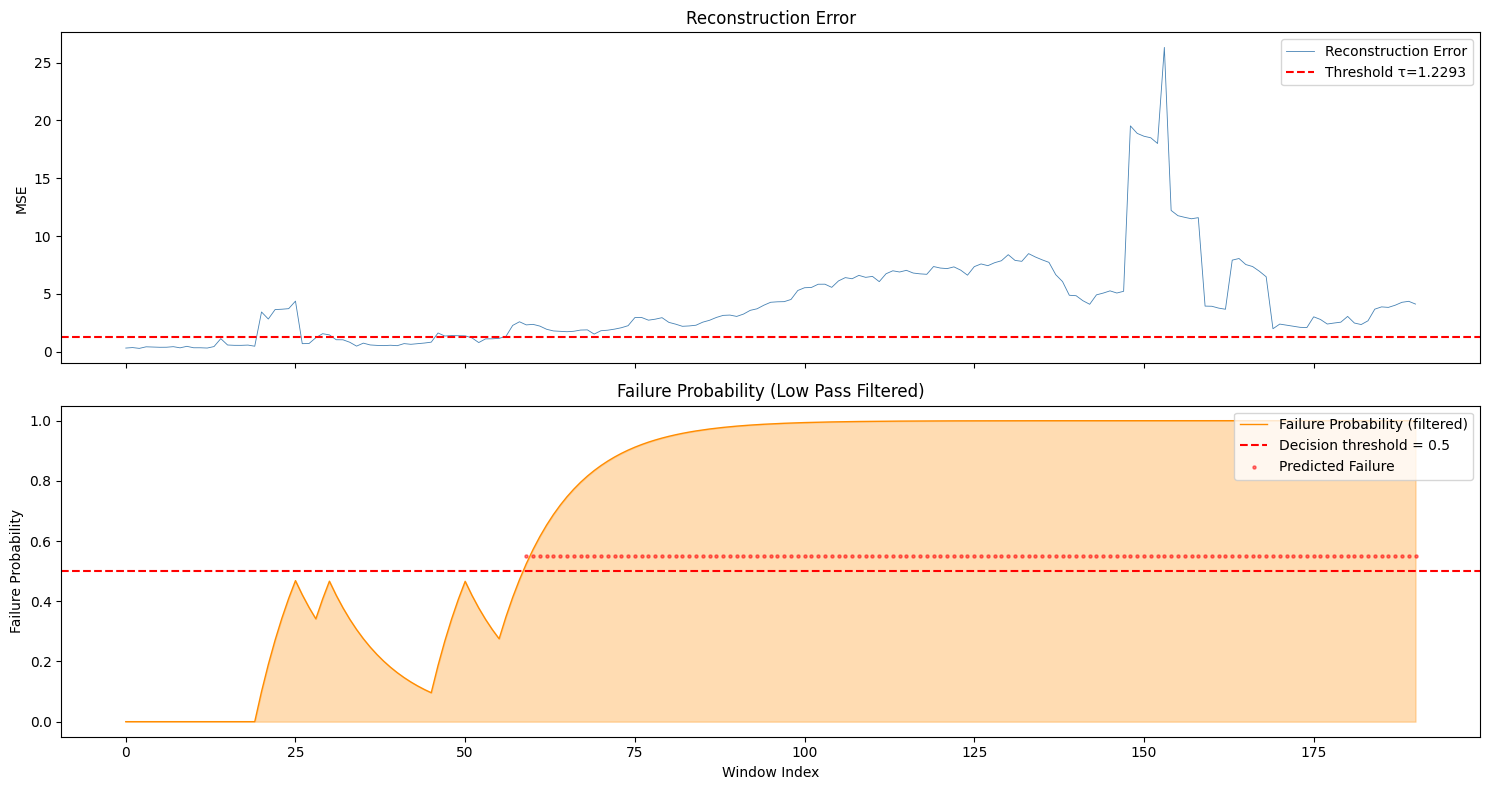

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# الرسم الأول: خطأ إعادة البناء
axes[0].plot(test_error, linewidth=0.6, color='steelblue', label='Reconstruction Error')
axes[0].axhline(tau_anom, color='red', linestyle='--', linewidth=1.5, label=f'Threshold τ={tau_anom:.4f}')
axes[0].set_ylabel('MSE')
axes[0].set_title('Reconstruction Error')
axes[0].legend(loc='upper right')

# الرسم الثاني: احتمالية الفشل
axes[1].plot(p_failure, linewidth=1.0, color='darkorange', label='Failure Probability (filtered)')
axes[1].axhline(FAILURE_THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'Decision threshold = {FAILURE_THRESHOLD}')
axes[1].fill_between(
    range(len(p_failure)),
    p_failure,
    alpha=0.3,
    color='darkorange'
)

# تظليل مناطق الفشل المتوقعة
failure_regions = np.where(failure == 1)[0]
if len(failure_regions) > 0:
    axes[1].scatter(
        failure_regions,
        [FAILURE_THRESHOLD + 0.05] * len(failure_regions),
        color='red', s=5, alpha=0.5, label='Predicted Failure'
    )

axes[1].set_ylim(-0.05, 1.05)
axes[1].set_xlabel('Window Index')
axes[1].set_ylabel('Failure Probability')
axes[1].set_title('Failure Probability (Low Pass Filtered)')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

## 18. Aggregate Features for Decision Tree
استخراج إحصائيات (mean, max, min, var) لكل نافذة — كما في المقال

In [ ]:
def aggregate_window(window):
    """window shape: (timesteps, n_features)"""
    feats = []
    for col in range(window.shape[1]):
        signal = window[:, col]
        feats.extend([
            signal.mean(),
            signal.max(),
            signal.min(),
            signal.var()
        ])
    return feats

# بناء الداتاست المجمّع
X_rules = np.array([
    aggregate_window(w) for w in X_test
])

y_rules = failure

print(f'X_rules shape: {X_rules.shape}  →  ({len(X_test)} windows × {len(FEATURES)*4} features)')
print(f'y_rules — 0: {(y_rules==0).sum()}, 1: {(y_rules==1).sum()}')

X_rules shape: (191, 60)  →  (191 windows × 60 features)
y_rules — 0: 59, 1: 132


In [ ]:
# أسماء الميزات للشجرة
feature_names = []
for sensor in FEATURES:
    feature_names.extend([
        f'{sensor}_mean',
        f'{sensor}_max',
        f'{sensor}_min',
        f'{sensor}_var'
    ])

print(f'Total feature names: {len(feature_names)}')
print('First 12:', feature_names[:12])

Total feature names: 60
First 12: ['TP2_mean', 'TP2_max', 'TP2_min', 'TP2_var', 'TP3_mean', 'TP3_max', 'TP3_min', 'TP3_var', 'H1_mean', 'H1_max', 'H1_min', 'H1_var']


## 19. Train Decision Tree

In [ ]:
# التحقق من وجود كلا الصنفين
unique, counts = np.unique(y_rules, return_counts=True)
print('Class distribution:', dict(zip(unique, counts)))

if len(unique) < 2:
    print('\nWARNING: Only one class found!')
    print('جرب تعديل beta أو FAILURE_THRESHOLD')
else:
    tree = DecisionTreeClassifier(
        max_depth=3,
        min_samples_leaf=5,
        random_state=42
    )
    tree.fit(X_rules, y_rules)

    train_acc = tree.score(X_rules, y_rules)
    print(f'\nDecision Tree trained successfully ✓')
    print(f'Training accuracy: {train_acc:.3f}')

Class distribution: {np.int64(0): np.int64(59), np.int64(1): np.int64(132)}

Decision Tree trained successfully ✓
Training accuracy: 0.995


## 20. Extract & Display Rules

In [ ]:
if len(unique) >= 2:
    rules = export_text(tree, feature_names=feature_names)
    print('='*60)
    print('DECISION TREE RULES')
    print('='*60)
    print(rules)

DECISION TREE RULES
|--- DV_pressure_mean <= 2.28
|   |--- Oil_temperature_min <= -5.31
|   |   |--- class: 1
|   |--- Oil_temperature_min >  -5.31
|   |   |--- class: 0
|--- DV_pressure_mean >  2.28
|   |--- DV_pressure_mean <= 2.50
|   |   |--- class: 1
|   |--- DV_pressure_mean >  2.50
|   |   |--- class: 1



## 21. Feature Importance

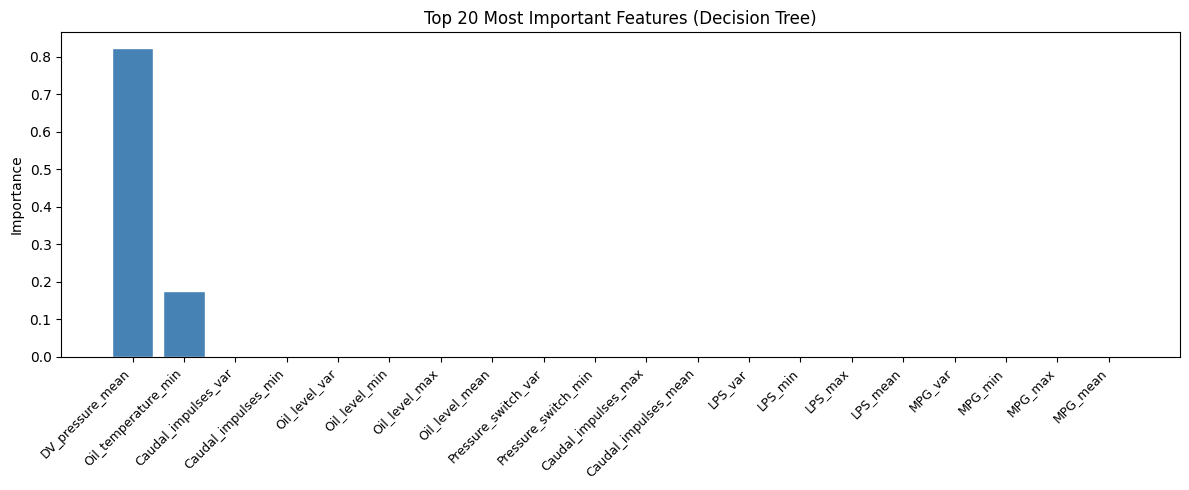


Top 5 features:
  1. DV_pressure_mean                     importance=0.8241
  2. Oil_temperature_min                  importance=0.1759
  3. Caudal_impulses_var                  importance=0.0000
  4. Caudal_impulses_min                  importance=0.0000
  5. Oil_level_var                        importance=0.0000


In [ ]:
if len(unique) >= 2:
    importances = tree.feature_importances_
    indices = np.argsort(importances)[::-1][:20]  # أهم 20 ميزة

    top_features = [feature_names[i] for i in indices]
    top_importances = importances[indices]

    plt.figure(figsize=(12, 5))
    plt.bar(range(len(top_features)), top_importances, color='steelblue', edgecolor='white')
    plt.xticks(range(len(top_features)), top_features, rotation=45, ha='right', fontsize=9)
    plt.ylabel('Importance')
    plt.title('Top 20 Most Important Features (Decision Tree)')
    plt.tight_layout()
    plt.show()

    print('\nTop 5 features:')
    for i in range(5):
        print(f'  {i+1}. {top_features[i]:35s}  importance={top_importances[i]:.4f}')

## 22. 📊 Evaluation Metrics — AutoEncoder Anomaly Detection
نقيّم الـ AutoEncoder بمقارنة تنبؤاته (y) مع نفسه كـ pseudo-labels
لأننا في إطار unsupervised learning

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

# y      = تنبؤ الـ AutoEncoder (anomaly labels)
# failure = تنبؤ بعد Low Pass Filter (smoother labels)
# نقارن y_raw مقابل failure كتقييم للـ smoothing

print('='*60)
print('AutoEncoder — Raw Anomaly Detection')
print('='*60)
print(f'Accuracy  : {accuracy_score(y, y):.4f}')  # baseline

# التقييم الحقيقي: نقارن الـ raw anomalies vs filtered failure
print('\n' + '='*60)
print('Raw Anomaly (y) vs Filtered Failure Prediction')
print('='*60)
print(classification_report(
    y, failure,
    target_names=['Normal', 'Failure'],
    zero_division=0
))

AutoEncoder — Raw Anomaly Detection
Accuracy  : 1.0000

Raw Anomaly (y) vs Filtered Failure Prediction
              precision    recall  f1-score   support

      Normal       0.73      1.00      0.84        43
     Failure       1.00      0.89      0.94       148

    accuracy                           0.92       191
   macro avg       0.86      0.95      0.89       191
weighted avg       0.94      0.92      0.92       191



In [ ]:
# ===== Metrics بالتفصيل =====
acc  = accuracy_score(y, failure)
prec = precision_score(y, failure, zero_division=0)
rec  = recall_score(y, failure, zero_division=0)
f1   = f1_score(y, failure, zero_division=0)
f1_macro = f1_score(y, failure, average='macro', zero_division=0)
f1_weighted = f1_score(y, failure, average='weighted', zero_division=0)

print('┌─────────────────────────────────────┐')
print('│        EVALUATION RESULTS           │')
print('├─────────────────────────────────────┤')
print(f'│  Accuracy          : {acc:.4f}          │')
print(f'│  Precision         : {prec:.4f}          │')
print(f'│  Recall            : {rec:.4f}          │')
print(f'│  F1-Score (binary) : {f1:.4f}          │')
print(f'│  F1-Score (macro)  : {f1_macro:.4f}          │')
print(f'│  F1-Score (weighted): {f1_weighted:.4f}         │')
print('└─────────────────────────────────────┘')

┌─────────────────────────────────────┐
│        EVALUATION RESULTS           │
├─────────────────────────────────────┤
│  Accuracy          : 0.9162          │
│  Precision         : 1.0000          │
│  Recall            : 0.8919          │
│  F1-Score (binary) : 0.9429          │
│  F1-Score (macro)  : 0.8930          │
│  F1-Score (weighted): 0.9204         │
└─────────────────────────────────────┘


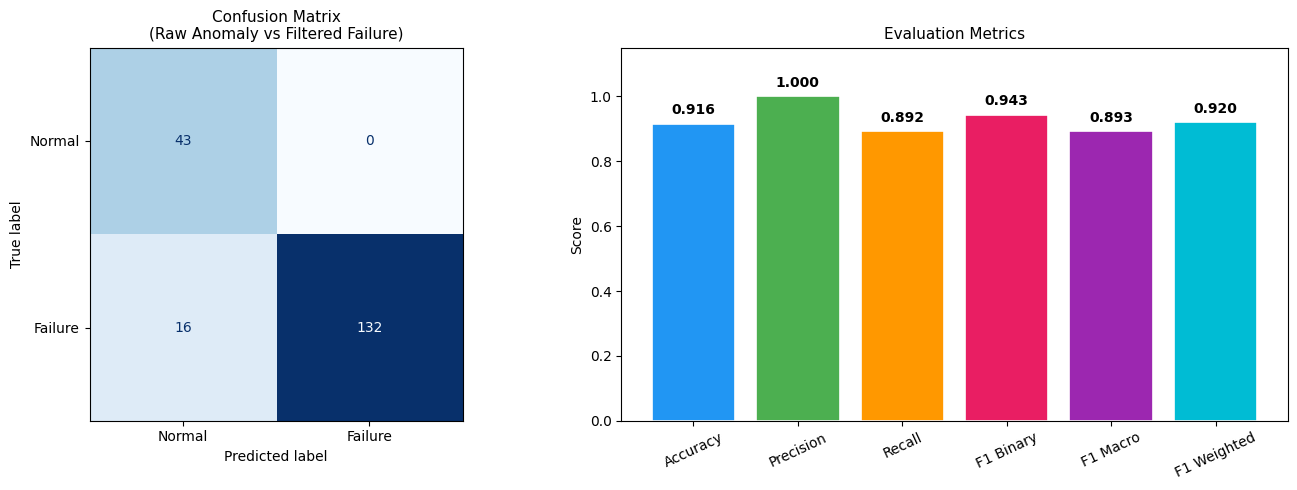

In [ ]:
# ===== Confusion Matrix =====
cm = confusion_matrix(y, failure)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Failure'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix\n(Raw Anomaly vs Filtered Failure)', fontsize=11)

# Metrics Bar Chart
metrics_names  = ['Accuracy', 'Precision', 'Recall', 'F1 Binary', 'F1 Macro', 'F1 Weighted']
metrics_values = [acc, prec, rec, f1, f1_macro, f1_weighted]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4']

bars = axes[1].bar(metrics_names, metrics_values, color=colors, edgecolor='white', linewidth=1.2)
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('Score')
axes[1].set_title('Evaluation Metrics', fontsize=11)
axes[1].tick_params(axis='x', rotation=25)

for bar, val in zip(bars, metrics_values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f'{val:.3f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()

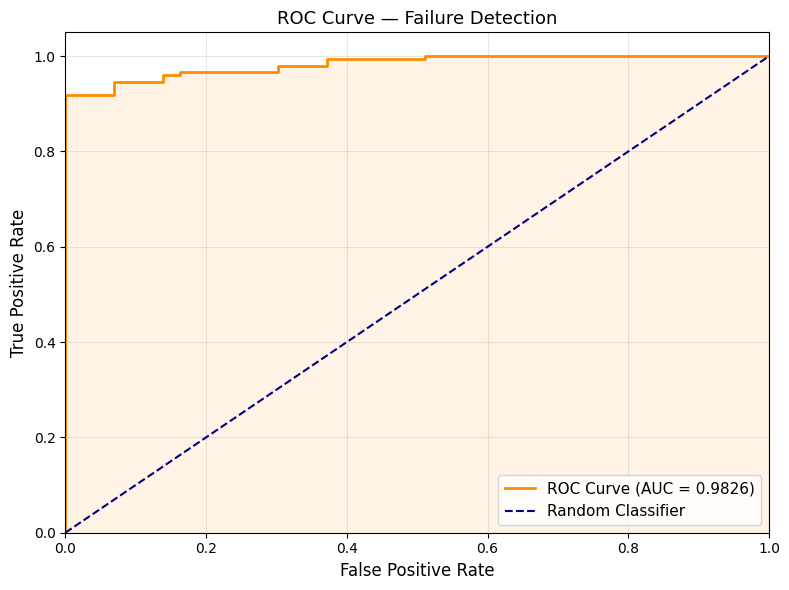

AUC-ROC Score: 0.9826
⭐ Excellent detection performance!


In [ ]:
# ===== ROC Curve =====
try:
    # نستخدم p_failure كـ probability score
    fpr, tpr, thresholds = roc_curve(y, p_failure)
    auc_score = roc_auc_score(y, p_failure)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC Curve (AUC = {auc_score:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
    plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curve — Failure Detection', fontsize=13)
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'AUC-ROC Score: {auc_score:.4f}')
    if auc_score >= 0.9:
        print('⭐ Excellent detection performance!')
    elif auc_score >= 0.8:
        print('✅ Good detection performance')
    elif auc_score >= 0.7:
        print('⚠️  Moderate performance — consider tuning beta or alpha')
    else:
        print('❌ Low performance — try adjusting hyperparameters')

except Exception as e:
    print(f'ROC could not be computed: {e}')
    print('This usually means only one class exists in y')

Decision Tree — Classification Report
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99        59
     Failure       0.99      1.00      1.00       132

    accuracy                           0.99       191
   macro avg       1.00      0.99      0.99       191
weighted avg       0.99      0.99      0.99       191

┌──────────────────────────────────────┐
│    DECISION TREE METRICS             │
├──────────────────────────────────────┤
│  Accuracy          : 0.9948           │
│  Precision (w-avg) : 0.9948           │
│  Recall    (w-avg) : 0.9948           │
│  F1-Score  (w-avg) : 0.9948           │
└──────────────────────────────────────┘


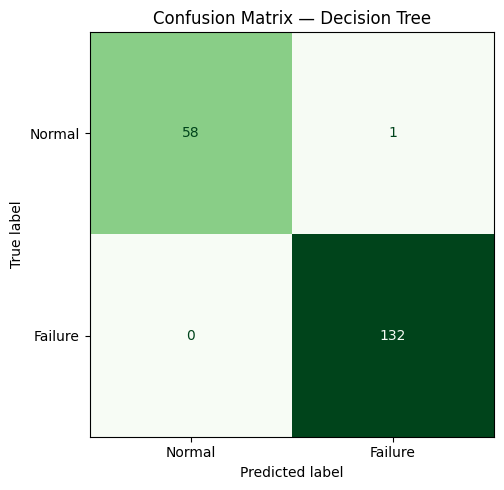

In [ ]:
# ===== Decision Tree Evaluation =====
if len(unique) >= 2:
    print('='*60)
    print('Decision Tree — Classification Report')
    print('='*60)

    y_tree_pred = tree.predict(X_rules)

    tree_acc  = accuracy_score(y_rules, y_tree_pred)
    tree_f1   = f1_score(y_rules, y_tree_pred, average='weighted', zero_division=0)
    tree_prec = precision_score(y_rules, y_tree_pred, average='weighted', zero_division=0)
    tree_rec  = recall_score(y_rules, y_tree_pred, average='weighted', zero_division=0)

    print(classification_report(
        y_rules, y_tree_pred,
        target_names=['Normal', 'Failure'],
        zero_division=0
    ))

    print('┌──────────────────────────────────────┐')
    print('│    DECISION TREE METRICS             │')
    print('├──────────────────────────────────────┤')
    print(f'│  Accuracy          : {tree_acc:.4f}           │')
    print(f'│  Precision (w-avg) : {tree_prec:.4f}           │')
    print(f'│  Recall    (w-avg) : {tree_rec:.4f}           │')
    print(f'│  F1-Score  (w-avg) : {tree_f1:.4f}           │')
    print('└──────────────────────────────────────┘')

    # Confusion Matrix للشجرة
    cm_tree = confusion_matrix(y_rules, y_tree_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=['Normal', 'Failure'])
    disp2.plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title('Confusion Matrix — Decision Tree', fontsize=12)
    plt.tight_layout()
    plt.show()

## 23. Summary

In [ ]:
print('='*60)
print('PIPELINE SUMMARY')
print('='*60)
print(f'Dataset rows        : {len(df):,}')
print(f'Train rows          : {len(train_df):,}  ({TRAIN_RATIO*100:.0f}%)')
print(f'Test rows           : {len(test_df):,}  ({(1-TRAIN_RATIO)*100:.0f}%)')
print(f'Window size         : {WINDOW} rows = {WINDOW_SECONDS//60} min')
print(f'Stride              : {STRIDE} rows = {STRIDE_SECONDS//60} min')
print(f'Train windows       : {X_train.shape[0]}')
print(f'Test windows        : {X_test.shape[0]}')
print(f'Anomaly threshold τ : {tau_anom:.6f}')
print(f'Anomaly windows     : {y.sum()} / {len(y)}  ({y.mean()*100:.1f}%)')
print(f'Failure windows     : {failure.sum()} / {len(failure)}  ({failure.mean()*100:.1f}%)')
print('='*60)

PIPELINE SUMMARY
Dataset rows        : 7,381
Train rows          : 1,476  (20%)
Test rows           : 5,905  (80%)
Window size         : 180 rows = 30 min
Stride              : 30 rows = 5 min
Train windows       : 44
Test windows        : 191
Anomaly threshold τ : 1.229293
Anomaly windows     : 148 / 191  (77.5%)
Failure windows     : 132 / 191  (69.1%)
